## 怎么理解 `class Net(nn.Module)`

带两个隐藏层（各 256 单元）、自带丢弃法的多层感知机。

**① 继承基类**：`nn.Module` 是 PyTorch 所有网络的基类，继承它就能自动管理参数、自动求导、能被 `.to('cuda')` 搬运。

**② `__init__`（搭积木）**：定义网络包含哪些层，创建对象时自动执行：

```python
def __init__(self, num_inputs, num_outputs, num_hiddens1, num_hiddens2):
    super().__init__()
    self.lin1 = nn.Linear(num_inputs, num_hiddens1)    # 784 → 256
    self.lin2 = nn.Linear(num_hiddens1, num_hiddens2)  # 256 → 256
    self.lin3 = nn.Linear(num_hiddens2, num_outputs)   # 256 → 10
    self.relu = nn.ReLU()
```

**③ `forward`（流水线）**：定义数据怎么流动，每次 `net(X)` 都执行：

```python
def forward(self, X):
    H1 = self.relu(self.lin1(X.reshape((-1, self.num_inputs))))
    if self.training == True:
        H1 = dropout_layer(H1, dropout1)   # 第一隐藏层丢弃 0.2
    H2 = self.relu(self.lin2(H1))
    if self.training == True:
        H2 = dropout_layer(H2, dropout2)   # 第二隐藏层丢弃 0.5
    out = self.lin3(H2)
    return out
```

路径：展平(784) → lin1 → relu → [训练时丢弃0.2] → lin2 → relu → [训练时丢弃0.5] → lin3 → 输出 10 个数

丢弃法只在 `self.training == True`（训练时）生效；测试时所有神经元都参与，输出才稳定。


对X加入噪音得到X1，我们希望E(X1)=X
于是我们对于每个元素做出如下扰动：
$$
h' =
\begin{cases}
0, & \text{以概率 } p \text{（丢弃）} \\
\dfrac{h}{1 - p}, & \text{以概率 } 1 - p \text{（保留并缩放）}
\end{cases}
$$
通常将丢弃法作用在隐藏全连接层的输出上

In [25]:
import torch
from torch import nn
from d2l import torch as d2l
from good_functions import *

def dropout_layer(X,drop_out):
    assert 0<=drop_out<=1
    if drop_out==1:
        return torch.zeros_like(X)
    if drop_out==0:
        return (X)
    mask=(torch.rand(X.shape, device=X.device)>drop_out).float()
    return  mask*X/(1.0-drop_out)

mask是决定这个神经元开不开的关键，是生成一个和X形状相同的矩阵，然后和每个元素都是drop_out的矩阵比大小。概率当然是1-p喽

定义具有两个隐藏层的多层感知机，每个隐藏层有256个单元

In [26]:
nun_inputs,num_outputs,num_hiddens1,num_hiddens2=784,10,256,64

dropout1,dropout2=0.5,0.5

class Net(nn.Module):
    def __init__(self,num_inputs,num_outputs,num_hiddens1,num_hiddens2,is_training=True):
        super(Net,self).__init__()
        self.num_inputs = num_inputs
        self.training = is_training
        self.lin1=nn.Linear(self.num_inputs,num_hiddens1)
        self.lin2=nn.Linear(num_hiddens1,num_hiddens2)
        self.lin3=nn.Linear(num_hiddens2,num_outputs)
        self.relu=nn.ReLU()
    def forward(self,X):
        H1=self.relu(self.lin1(X.reshape((-1,self.num_inputs))))
        if self.training==True:
            H1=dropout_layer(H1,dropout1)
        H2=self.relu(self.lin2(H1))
        if self.training==True:
            H2=dropout_layer(H2,dropout2)
        out=self.lin3(H2)
        return out
net=Net(nun_inputs,num_outputs,num_hiddens1,num_hiddens2)

训练和测试

done — loss 0.2720, train acc 0.9004, test acc 0.8859


(0.2719648297548294, 0.9003833333333333)

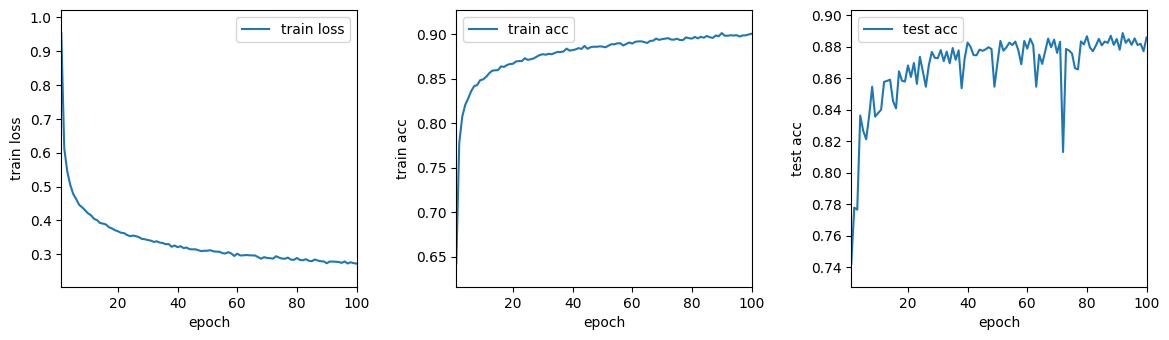

In [27]:
num_epochs,lr,batch_size=100,0.5,256
loss=nn.CrossEntropyLoss()
train_iter,test_iter=d2l.load_data_fashion_mnist(batch_size)
trainer = torch.optim.SGD(net.parameters(),lr=lr)
train_ch3_gpu(net, train_iter, test_iter, loss, num_epochs, trainer)